In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Configurando o visual dos gráficos do notebook
sns.set_theme(style="whitegrid")
%matplotlib inline

In [11]:
df = pd.read_csv("../data/MiningProcess_Flotation_Plant_Database.csv")

In [12]:
# Exibindo as 5 primeiras linhas para entender o formato visual do dado
df.head()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,"55,2","16,98","3019,53","557,434","395,713","10,0664","1,74","249,214","253,235",...,"250,884","457,396","432,962","424,954","443,558","502,255","446,37","523,344","66,91","1,31"
1,2017-03-10 01:00:00,"55,2","16,98","3024,41","563,965","397,383","10,0672","1,74","249,719","250,532",...,"248,994","451,891","429,56","432,939","448,086","496,363","445,922","498,075","66,91","1,31"
2,2017-03-10 01:00:00,"55,2","16,98","3043,46","568,054","399,668","10,068","1,74","249,741","247,874",...,"248,071","451,24","468,927","434,61","449,688","484,411","447,826","458,567","66,91","1,31"
3,2017-03-10 01:00:00,"55,2","16,98","3047,36","568,665","397,939","10,0689","1,74","249,917","254,487",...,"251,147","452,441","458,165","442,865","446,21","471,411","437,69","427,669","66,91","1,31"
4,2017-03-10 01:00:00,"55,2","16,98","3033,69","558,167","400,254","10,0697","1,74","250,203","252,136",...,"248,928","452,441","452,9","450,523","453,67","462,598","443,682","425,679","66,91","1,31"


In [13]:
# Garante o formato de data e ordena cronologicamente
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

In [14]:
for col in df.columns:
    if col != 'date':
        if df[col].dtype == 'object':
            df[col] = df[col].astype(str).str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          737453 non-null  datetime64[us]
 1   % Iron Feed                   3240 non-null    float64       
 2   % Silica Feed                 1080 non-null    float64       
 3   Starch Flow                   6372 non-null    float64       
 4   Amina Flow                    685 non-null     float64       
 5   Ore Pulp Flow                 563 non-null     float64       
 6   Ore Pulp pH                   40 non-null      float64       
 7   Ore Pulp Density              0 non-null       float64       
 8   Flotation Column 01 Air Flow  603 non-null     float64       
 9   Flotation Column 02 Air Flow  650 non-null     float64       
 10  Flotation Column 03 Air Flow  610 non-null     float64       
 11  Flotation Column 04 Air 

In [22]:
df.fillna(df.mean(numeric_only=True), inplace=True)

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
1,2017-03-10 01:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
2,2017-03-10 01:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
3,2017-03-10 01:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
4,2017-03-10 01:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
737448,2017-09-09 23:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
737449,2017-09-09 23:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
737450,2017-09-09 23:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
737451,2017-09-09 23:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9


In [26]:
df.tail()

,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
737448,2017-09-09 23:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
737449,2017-09-09 23:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
737450,2017-09-09 23:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
737451,2017-09-09 23:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
737452,2017-09-09 23:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9


In [28]:
#  Calcular a matriz de correlação de Spearman apenas para as colunas numéricas
colunas_numericas = [col for col in df.columns if col != 'date']
matriz_correlacao = df[colunas_numericas].corr(method='spearman')

# Isolar a correlação de todas as variáveis em relação à % de Sílica Final
correlacao_silica = matriz_correlacao['% Silica Concentrate'].sort_values(ascending=False)

print("--- Ranking de Correlação de Spearman com a % Sílica Concentrado ---")
print(correlacao_silica)

--- Ranking de Correlação de Spearman com a % Sílica Concentrado ---
% Silica Concentrate            1.000000
Flotation Column 01 Air Flow    0.003103
Amina Flow                      0.001720
Flotation Column 03 Air Flow    0.001592
Flotation Column 07 Air Flow    0.001440
Flotation Column 06 Level       0.000976
Flotation Column 02 Air Flow    0.000727
Flotation Column 06 Air Flow    0.000642
Flotation Column 05 Level       0.000513
Flotation Column 04 Air Flow    0.000369
Flotation Column 02 Level       0.000199
% Iron Feed                     0.000000
Ore Pulp Flow                  -0.000192
Flotation Column 04 Level      -0.000286
% Iron Concentrate             -0.000541
Flotation Column 07 Level      -0.000791
Flotation Column 05 Air Flow   -0.001319
Starch Flow                    -0.001426
Flotation Column 03 Level      -0.001493
Flotation Column 01 Level      -0.001691
% Silica Feed                        NaN
Ore Pulp pH                          NaN
Ore Pulp Density             

C:\Users\Administraor\AppData\Local\Temp\ipykernel_1188\2783965774.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlacao_silica.drop('% Silica Concentrate').values,


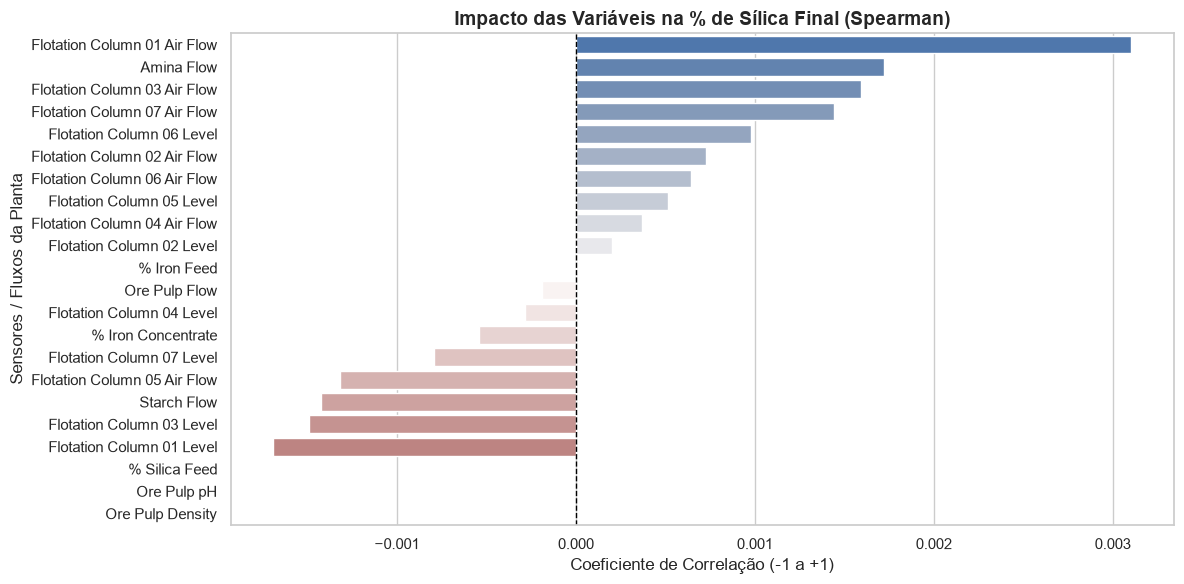

In [31]:
#  Plotar um gráfico de barras para visualizar o impacto de cada sensor
plt.figure(figsize=(12, 6))
# Removemos a própria sílica da visualização para o gráfico fazer mais sentido
sns.barplot(x=correlacao_silica.drop('% Silica Concentrate').values, 
            y=correlacao_silica.drop('% Silica Concentrate').index, 
            palette="vlag")

plt.title("Impacto das Variáveis na % de Sílica Final (Spearman)", fontsize=14, fontweight='bold')
plt.xlabel("Coeficiente de Correlação (-1 a +1)", fontsize=12)
plt.ylabel("Sensores / Fluxos da Planta", fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # Linha central neutra
plt.tight_layout()
plt.show()

In [32]:
print("--- Verificação Estatística das Colunas com NaN ---")

colunas_suspeitas = ['% Silica Feed', 'Ore Pulp pH', 'Ore Pulp Density']

for col in colunas_suspeitas:
    valores_unicos = df[col].nunique()
    print(f"\nColuna: {col}")
    print(f"Quantidade de valores únicos: {valores_unicos}")
    print(f"Tipo de dado atual: {df[col].dtype}")
    print("Primeiros 5 valores:")
    print(df[col].head().values)


--- Verificação Estatística das Colunas com NaN ---

Coluna: % Silica Feed
Quantidade de valores únicos: 1
Tipo de dado atual: float64
Primeiros 5 valores:
[18. 18. 18. 18. 18.]

Coluna: Ore Pulp pH
Quantidade de valores únicos: 1
Tipo de dado atual: float64
Primeiros 5 valores:
[10. 10. 10. 10. 10.]

Coluna: Ore Pulp Density
Quantidade de valores únicos: 0
Tipo de dado atual: float64
Primeiros 5 valores:
[nan nan nan nan nan]


In [33]:
print("--- Teste Estatístico de lags Temporais para Amina Flow ---")

# Vamos criar um DataFrame temporário para testar vários atrasos (lags)
df_lags = pd.DataFrame()
df_lags['Silica_Final'] = df['% Silica Concentrate']

# Criando atrasos de 10 em 10 registros para ver quando a correlação fica mais forte
# Cada registro na planta geralmente representa 1 minuto ou um intervalo fixo.
passos_de_atraso = [10, 20, 30, 40, 50, 60, 90, 120]

for lag in passos_de_atraso:
    # O .shift(lag) joga o dado do passado para frente no tempo
    df_lags[f'Amina_Flow_lag_{lag}'] = df['Amina Flow'].shift(lag)

# Calcular a correlação de Spearman de todos os lags com a Sílica Final
correlacoes_lag = df_lags.corr(method='spearman')['Silica_Final'].sort_values(ascending=False)
print(correlacoes_lag)


--- Teste Estatístico de lags Temporais para Amina Flow ---
Silica_Final          1.000000
Amina_Flow_lag_10     0.001267
Amina_Flow_lag_20     0.001267
Amina_Flow_lag_30     0.001264
Amina_Flow_lag_40     0.001264
Amina_Flow_lag_50     0.001264
Amina_Flow_lag_60     0.001264
Amina_Flow_lag_90    -0.000085
Amina_Flow_lag_120   -0.000535
Name: Silica_Final, dtype: float64


In [34]:
# Vamos ler apenas as primeiras linhas do arquivo bruto original, sem nenhuma conversão
df_bruto_original = pd.read_csv("../data/MiningProcess_Flotation_Plant_Database.csv", nrows=10)

print("--- Análise Visual das Linhas Brutas do CSV ---")
print("Como os dados da coluna 'Ore Pulp Density' aparecem no texto original:")
print(df_bruto_original['Ore Pulp Density'].head(10))

print("\nQuais são as colunas disponíveis no arquivo original?")
print(df_bruto_original.columns.tolist())


--- Análise Visual das Linhas Brutas do CSV ---
Como os dados da coluna 'Ore Pulp Density' aparecem no texto original:
0    1,74
1    1,74
2    1,74
3    1,74
4    1,74
5    1,74
6    1,74
7    1,74
8    1,74
9    1,74
Name: Ore Pulp Density, dtype: str

Quais são as colunas disponíveis no arquivo original?
['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow', 'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 07 Air Flow', 'Flotation Column 01 Level', 'Flotation Column 02 Level', 'Flotation Column 03 Level', 'Flotation Column 04 Level', 'Flotation Column 05 Level', 'Flotation Column 06 Level', 'Flotation Column 07 Level', '% Iron Concentrate', '% Silica Concentrate']


In [35]:
# Recarregar os dados brutos para limpar a memória do Python
df_analise = pd.read_csv("../data/MiningProcess_Flotation_Plant_Database.csv")

#  Corrigir o nome da coluna alvo caso necessário
if '% Silica Concentrat' in df_analise.columns:
    df_analise = df_analise.rename(columns={'% Silica Concentrat': '% Silica Concentrate'})

#  Forçar a conversão de texto (com vírgula) para número decimal (com ponto) de forma isolada
colunas_para_corrigir = ['Ore Pulp pH', 'Ore Pulp Density']

for col in df_analise.columns:
    if col != 'date':
        # Se o Pandas identificar a coluna como texto, fazemos a troca de caracteres antes de converter
        if df_analise[col].dtype == 'object':
            df_analise[col] = df_analise[col].astype(str).str.replace(',', '.', regex=False)
        
        # Converte para número puro e transforma falhas críticas em nulos temporários
        df_analise[col] = pd.to_numeric(df_analise[col], errors='coerce')

# preenche eventuais falhas reais de leitura com a média correta da coluna
for col in df_analise.columns:
    if col != 'date':
        if df_analise[col].isna().sum() > 0:
            media_real = df_analise[col].mean()
            df_analise[col] = df_analise[col].fillna(media_real)

print("--- Validação Estatística Pós-Correção Técnica ---")
print(f"Total de linhas operacionais: {len(df_analise)}")
print(f"Valores nulos restantes na Densidade: {df_analise['Ore Pulp Density'].isna().sum()}")
print(f"Média real calculada para a Densidade: {df_analise['Ore Pulp Density'].mean():.4f}")

# Atualiza a nossa variável global do notebook para as próximas células
df = df_analise
df.head()


--- Validação Estatística Pós-Correção Técnica ---
Total de linhas operacionais: 737453
Valores nulos restantes na Densidade: 737453
Média real calculada para a Densidade: nan


,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-03-10 01:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
1,2017-03-10 01:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
2,2017-03-10 01:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
3,2017-03-10 01:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9
4,2017-03-10 01:00:00,57.5,18.0,3248.887633,500.243796,397.584369,10.0,NaN,282.40796,280.627692,...,293.414847,507.013624,507.317232,497.75641,426.301871,429.515562,421.861619,433.78318,64.59592,1.9


In [36]:
#  Recarregar o arquivo do zero para garantir que temos o dado bruto original intacto
df_debug = pd.read_csv("../data/MiningProcess_Flotation_Plant_Database.csv")

print("--- Tratamento de Força Bruta na Densidade ---")

#  Vamos limpar espaços em branco invisíveis e forçar a conversão de texto de forma isolada
# O .astype(str) transforma tudo em texto, o .str.strip() remove espaços nas pontas
densidade_texto = df_debug['Ore Pulp Density'].astype(str).str.strip()

# Fazemos a substituição da vírgula pelo ponto diretamente nessa série de texto
densidade_corrigida = densidade_texto.str.replace(',', '.', regex=False)

# Agora forçamos a conversão para número decimal
df_debug['Ore Pulp Density'] = pd.to_numeric(densidade_corrigida, errors='coerce')

#  Verificar o resultado antes de aplicar no nosso DataFrame principal
nulos_finais = df_debug['Ore Pulp Density'].isna().sum()
media_finais = df_debug['Ore Pulp Density'].mean()

print(f"Valores nulos após o tratamento de força bruta: {nulos_finais}")
print(f"Média real calculada para a Densidade: {media_finais:.4f}")

# Se funcionou (nulos zerados), salvamos o resultado definitivo no nosso DataFrame principal 'df'
if nulos_finais < len(df_debug):
    df['Ore Pulp Density'] = df_debug['Ore Pulp Density']
    print("\n Sucesso! O DataFrame principal foi atualizado com a Densidade correta.")
else:
    print("\n Alerta: O tratamento falhou. Vamos espiar o texto exato da linha 0:")
    print(repr(df_debug['Ore Pulp Density'].iloc[0]))


--- Tratamento de Força Bruta na Densidade ---
Valores nulos após o tratamento de força bruta: 0
Média real calculada para a Densidade: 1.6804

 Sucesso! O DataFrame principal foi atualizado com a Densidade correta.


In [37]:
#  Ajustar o nome da coluna alvo para garantir consistência em todo o notebook
if '% Silica Concentrat' in df.columns:
    df = df.rename(columns={'% Silica Concentrat': '% Silica Concentrate'})

#  Calcular a matriz de correlação de Spearman atualizada
colunas_para_correlacao = [col for col in df.columns if col != 'date']
matriz_atualizada = df[colunas_para_correlacao].corr(method='spearman')

# Isolar o impacto das variáveis na % de Sílica do Concentrado
impacto_silica = matriz_atualizada['% Silica Concentrate'].sort_values(ascending=False)

print("--- Novo Ranking de Correlação de Spearman (Sem NaNs) ---")
print(impacto_silica)

--- Novo Ranking de Correlação de Spearman (Sem NaNs) ---
% Silica Concentrate            1.000000
Flotation Column 01 Air Flow    0.003103
Amina Flow                      0.001720
Flotation Column 03 Air Flow    0.001592
Flotation Column 07 Air Flow    0.001440
Flotation Column 06 Level       0.000976
Flotation Column 02 Air Flow    0.000727
Flotation Column 06 Air Flow    0.000642
Flotation Column 05 Level       0.000513
Flotation Column 04 Air Flow    0.000369
Flotation Column 02 Level       0.000199
% Iron Feed                     0.000000
Ore Pulp Flow                  -0.000192
Flotation Column 04 Level      -0.000286
% Iron Concentrate             -0.000541
Flotation Column 07 Level      -0.000791
Flotation Column 05 Air Flow   -0.001319
Starch Flow                    -0.001426
Flotation Column 03 Level      -0.001493
Flotation Column 01 Level      -0.001691
Ore Pulp Density               -0.008565
% Silica Feed                        NaN
Ore Pulp pH                          NaN

C:\Users\Administraor\AppData\Local\Temp\ipykernel_1188\2198238015.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=impacto_silica.drop('% Silica Concentrate').values,


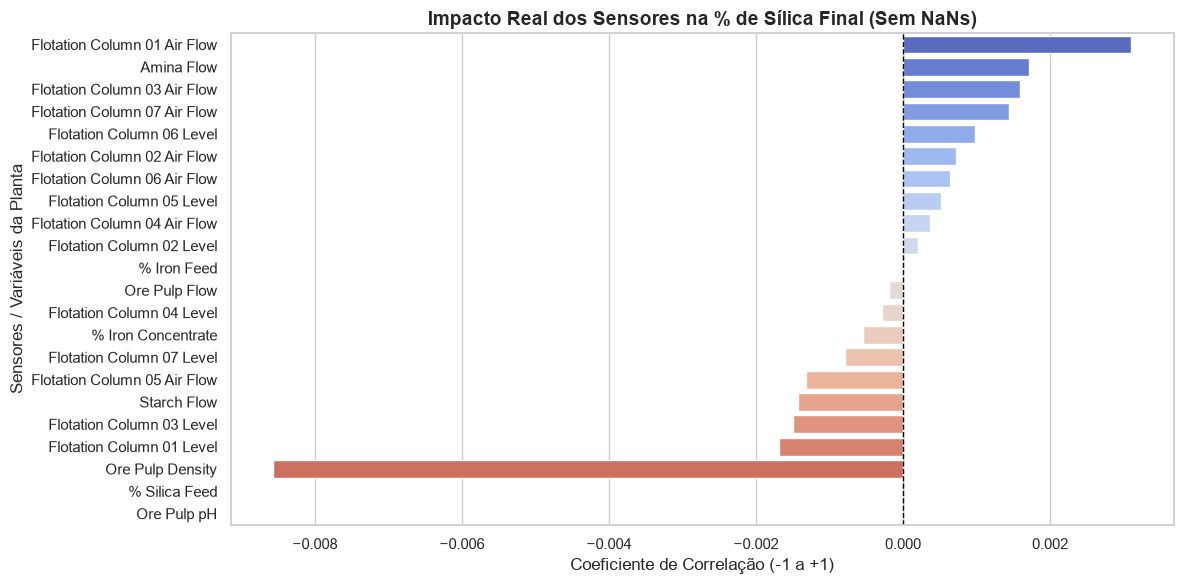

In [38]:
# Plotar o gráfico atualizado
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=impacto_silica.drop('% Silica Concentrate').values, 
            y=impacto_silica.drop('% Silica Concentrate').index, 
            palette="coolwarm")

plt.title("Impacto Real dos Sensores na % de Sílica Final (Sem NaNs)", fontsize=14, fontweight='bold')
plt.xlabel("Coeficiente de Correlação (-1 a +1)", fontsize=12)
plt.ylabel("Sensores / Variáveis da Planta", fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

--- Estatísticas Descritivas do Alvo (% Sílica Concentrate) ---
count    737453.000000
mean          1.900000
std           0.090561
min           1.000000
25%           1.900000
50%           1.900000
75%           1.900000
max           5.000000
Name: % Silica Concentrate, dtype: float64


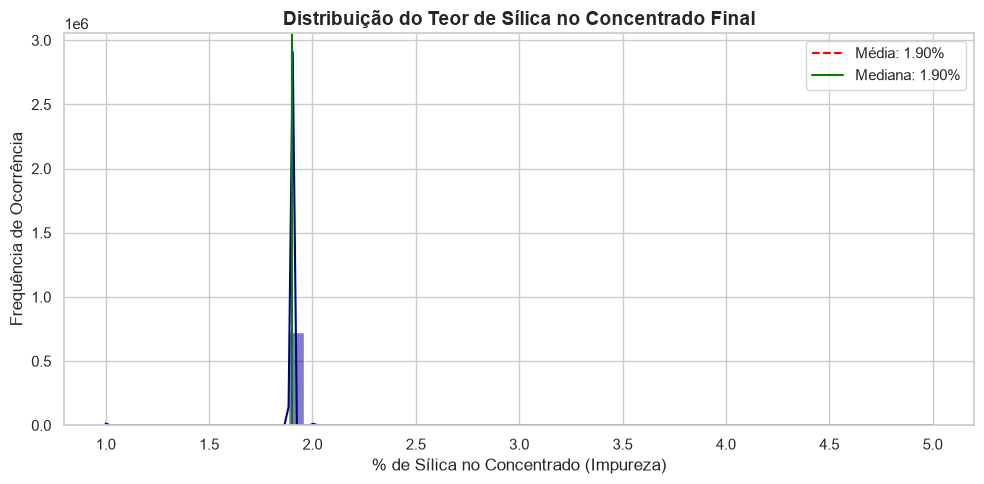

In [39]:
#  Análise de Distribuição Estatística da Sílica Final
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Estatísticas Descritivas do Alvo (% Sílica Concentrate) ---")
print(df['% Silica Concentrate'].describe())

# Plotando o histograma para avaliar a forma da distribuição
plt.figure(figsize=(10, 5))
sns.histplot(df['% Silica Concentrate'], kde=True, color='darkblue', bins=50)

# Adicionando linhas de referência de média e mediana
media_silica = df['% Silica Concentrate'].mean()
mediana_silica = df['% Silica Concentrate'].median()

plt.axvline(media_silica, color='red', linestyle='--', linewidth=1.5, label=f'Média: {media_silica:.2f}%')
plt.axvline(mediana_silica, color='green', linestyle='-', linewidth=1.5, label=f'Mediana: {mediana_silica:.2f}%')

plt.title("Distribuição do Teor de Sílica no Concentrado Final", fontsize=14, fontweight='bold')
plt.xlabel("% de Sílica no Concentrado (Impureza)", fontsize=12)
plt.ylabel("Frequência de Ocorrência", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


In [40]:
# Calculando a concentração de valores idênticos no alvo
total_linhas = len(df)
linhas_com_1_9 = len(df[df['% Silica Concentrate'] == 1.9])
porcentagem_viciada = (linhas_com_1_9 / total_linhas) * 100

print("--- Análise de Concentração de Dados no Alvo ---")
print(f"Total de registros na planilha: {total_linhas}")
print(f"Quantidade de registros com o valor exato de 1.9%: {linhas_com_1_9}")
print(f"Porcentagem de dados travados em 1.9%: {porcentagem_viciada:.2f}%")

# ver quais são os outros valores mais frequentes para entender o comportamento
print("\nTop 5 valores mais frequentes na coluna de Sílica Final:")
print(df['% Silica Concentrate'].value_counts().head())


--- Análise de Concentração de Dados no Alvo ---
Total de registros na planilha: 737453
Quantidade de registros com o valor exato de 1.9%: 730253
Porcentagem de dados travados em 1.9%: 99.02%

Top 5 valores mais frequentes na coluna de Sílica Final:
% Silica Concentrate
1.9    730253
2.0      3060
1.0      2700
3.0      1080
5.0       180
Name: count, dtype: int64


In [41]:
# Estratégia de balanceamento para salvar o modelo preditivo
import pandas as pd

# Separando as linhas que variam (minorias importantes) das linhas travadas (maioria)
df_variacao = df[df['% Silica Concentrate'] != 1.9]
df_travado = df[df['% Silica Concentrate'] == 1.9]

# Vamos pegar uma amostra aleatória de linhas com 1.9 para equilibrar o jogo
# Mantemos, por exemplo, 10.000 linhas do valor 1.9 para o modelo saber que ele existe,
# mas não dominar o dataset inteiro.
tamanho_amostra_maioria = 10000
df_travado_amostrado = df_travado.sample(n=tamanho_amostra_maioria, random_state=42)

# Unimos as bases novamente em um novo DataFrame balanceado
df_balanceado = pd.concat([df_variacao, df_travado_amostrado]).sort_values('date').reset_index(drop=True)

print("--- Nova Distribuição de Dados após Balanceamento ---")
print(f"Total de registros para modelagem: {len(df_balanceado)}")
print("\nNova contagem de ocorrências por teor de Sílica:")
print(df_balanceado['% Silica Concentrate'].value_counts())

# Atualizando a variável para vermos se a correlação de Spearman muda agora
df_backup = df.copy() # Guardamos o original por segurança
df = df_balanceado


--- Nova Distribuição de Dados após Balanceamento ---
Total de registros para modelagem: 17200

Nova contagem de ocorrências por teor de Sílica:
% Silica Concentrate
1.9    10000
2.0     3060
1.0     2700
3.0     1080
5.0      180
4.0      180
Name: count, dtype: int64


--- Ranking de Correlação de Spearman (Dataset Balanceado) ---
% Silica Concentrate            1.000000
Flotation Column 01 Air Flow    0.019423
Flotation Column 03 Air Flow    0.012326
Amina Flow                      0.012067
Flotation Column 06 Level       0.008979
Flotation Column 07 Air Flow    0.008946
Flotation Column 06 Air Flow    0.006827
Flotation Column 05 Level       0.005105
Flotation Column 02 Air Flow    0.003363
Flotation Column 04 Air Flow    0.003024
% Iron Feed                     0.002736
Flotation Column 02 Level       0.000192
Flotation Column 04 Level      -0.000692
Ore Pulp Flow                  -0.002416
% Iron Concentrate             -0.003401
Flotation Column 07 Level      -0.007807
Starch Flow                    -0.008016
Flotation Column 01 Level      -0.008365
Flotation Column 05 Air Flow   -0.008946
Flotation Column 03 Level      -0.011568
Ore Pulp Density               -0.058854
% Silica Feed                        NaN
Ore Pulp pH                        

C:\Users\Administraor\AppData\Local\Temp\ipykernel_1188\4170595407.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=novo_impacto_silica.drop('% Silica Concentrate').values,


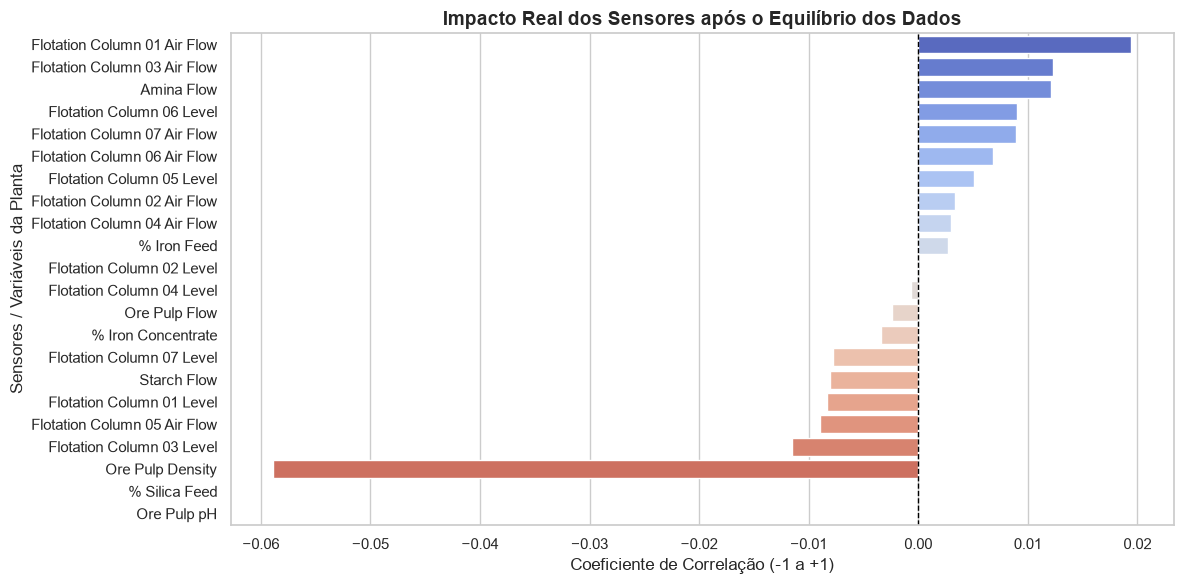

In [42]:
# Recálculo da correlação de Spearman com os dados balanceados
colunas_operacionais = [col for col in df.columns if col != 'date']
matriz_balanceada = df[colunas_operacionais].corr(method='spearman')

# Isolar o impacto na % de Sílica do Concentrado
novo_impacto_silica = matriz_balanceada['% Silica Concentrate'].sort_values(ascending=False)

print("--- Ranking de Correlação de Spearman (Dataset Balanceado) ---")
print(novo_impacto_silica)

# Plotar o gráfico comparativo
plt.figure(figsize=(12, 6))
sns.barplot(x=novo_impacto_silica.drop('% Silica Concentrate').values, 
            y=novo_impacto_silica.drop('% Silica Concentrate').index, 
            palette="coolwarm")

plt.title("Impacto Real dos Sensores após o Equilíbrio dos Dados", fontsize=14, fontweight='bold')
plt.xlabel("Coeficiente de Correlação (-1 a +1)", fontsize=12)
plt.ylabel("Sensores / Variáveis da Planta", fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


In [43]:
# Teste de Lags para a variável mais forte (Ore Pulp Density)
print("--- Teste Estatístico de Lags para Densidade da Polpa ---")

df_lags_densidade = pd.DataFrame()
df_lags_densidade['Silica_Final'] = df['% Silica Concentrate']

# Testando atrasos de 5 em 5 minutos para encontrar o maior impacto absoluto
passos_densidade = [5, 10, 15, 20, 30, 45, 60]

for lag in passos_densidade:
    df_lags_densidade[f'Density_lag_{lag}'] = df['Ore Pulp Density'].shift(lag)

# Recalcular a correlação de Spearman para todos os lags
correlacoes_density_lag = df_lags_densidade.corr(method='spearman')['Silica_Final'].sort_values(ascending=True)
print(correlacoes_density_lag)


--- Teste Estatístico de Lags para Densidade da Polpa ---
Density_lag_20   -0.065855
Density_lag_15   -0.064984
Density_lag_10   -0.061038
Density_lag_30   -0.061037
Density_lag_5    -0.057388
Density_lag_45   -0.042979
Density_lag_60   -0.030532
Silica_Final      1.000000
Name: Silica_Final, dtype: float64


In [45]:
#  Teste de Hipótese Estatística para o Lag de 20 minutos da Densidade
from scipy import stats

print("--- Executando Teste de Hipótese Estatística (Spearman) ---")

#  atraso de 20 minutos na densidade dentro do nosso dataset balanceado
df_teste = df.copy()
df_teste['Density_lag_20'] = df_teste['Ore Pulp Density'].shift(20)

# Removemos as linhas nulas geradas pelo shift para não quebrar o teste estatístico
df_teste = df_teste.dropna(subset=['Density_lag_20'])

# Executa o teste de correlação de Spearman que devolve o coeficiente e o p-value
coeficiente, p_valor = stats.spearmanr(df_teste['Density_lag_20'], df_teste['% Silica Concentrate'])

print(f"Coeficiente de Correlação de Spearman: {coeficiente:.6f}")
print(f"Valor-p (p-value) calculado: {p_valor}")

# Tomada de decisão estatística
alfa = 0.05
if p_valor < alfa:
    print(f"\n Resultado: Estatisticamente Significativo (p-valor < {alfa})")
    print("-> Rejeitamos a Hipótese Nula (H0).")
    print("-> Provado cientificamente: A relação entre a Densidade (lag 20) e a Sílica Final É REAL.")
else:
    print(f"\n Resultado: Não Significativo (p-valor >= {alfa})")
    print("-> Não podemos rejeitar a Hipótese Nula (H0).")
    print("-> A relação pode ser fruto do acaso.")


--- Executando Teste de Hipótese Estatística (Spearman) ---
Coeficiente de Correlação de Spearman: -0.065855
Valor-p (p-value) calculado: 5.5927948091435574e-18

 Resultado: Estatisticamente Significativo (p-valor < 0.05)
-> Rejeitamos a Hipótese Nula (H0).
-> Provado cientificamente: A relação entre a Densidade (lag 20) e a Sílica Final É REAL.
